# RFM + Soft Churn Predictive Analysis
This notebook loads `output.csv`, computes RFM segments, builds a soft churn label using observation/churn windows, trains a Decision Tree classifier, and saves outputs.

**Files expected:** `/mnt/data/output.csv`

In [3]:

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import timedelta

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt  # (only if you want plots)


In [4]:
# just checking where the file is

import os

folder = r"C:\Users\seahx\OneDrive\Documents\GitHub\bcg-rise-wave-11-group-2\Code"
print(os.listdir(folder))


['.ipynb_checkpoints', 'output.csv', 'rfm_segments.csv', 'RFM_SoftChurn_v01.ipynb', 'testJN_sarika (1).ipynb', 'xinni test 19-08-2025.ipynb', 'xinni test 21-08-2025.ipynb', 'xinni test.ipynb']


In [5]:

# Configuration
DATA_PATH = r"C:\Users\seahx\OneDrive\Documents\GitHub\bcg-rise-wave-11-group-2\Code\output.csv" # if u try it yourself, change the file loaction

OBSERVATION_DAYS = 180
CHURN_DAYS = 90
KMEANS_K = 4  # fast & stable
RANDOM_STATE = 42
MAX_DEPTH = 6


### Quick Data Cleaning
* change to datatime
* fill up missing data

In [7]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date', 'retailer_code'])



# If invoice_value is missing/zero, recompute
if 'invoice_value' not in df.columns or (df['invoice_value'].fillna(0)==0).all():
    df['invoice_value'] = df['price_sold'] * df['quantity_sold']



# Keep only positive sales (ignore returns for RFM/churn) -> but actually all is positive sales so this step not really necessary
df_sales = df[df['quantity_sold'] > 0].copy()
cutoff_date = df_sales['date'].max()

df.head()


,date,invoice_type,invoice_no,sku_code,product_category,brand_name,retailer_code,retailer_name,retailer_type,distributor_code,distributor_name,distributor_type,list_price,price_sold,quantity_sold,invoice_value
0,2021-04-01,Normal,QRA-006-21RT01000260-01,3995ffe6b5892f165984fa2555649ae9d0174753,FABRIC CARE,Brand 2,241abc9502c0ac90e9938a269dbfa9a2bbc54ef7,Retailer 192,CHAIN,Q006,Distributor B,Direct,12.6,8.70,12,104.4
1,2021-04-01,Normal,QRA-006-21RT01000260-01,d03a569bce6026abb692c1eb5b8b47e2e0bb5e8c,FABRIC CARE,Brand 2,241abc9502c0ac90e9938a269dbfa9a2bbc54ef7,Retailer 192,CHAIN,Q006,Distributor B,Direct,6.8,5.45,6,32.7
2,2021-04-01,Normal,QRA-006-21RT01000260-01,e0d4716ca0cc64bff1889f19aae1cf58ff270854,FABRIC CARE,Brand 2,241abc9502c0ac90e9938a269dbfa9a2bbc54ef7,Retailer 192,CHAIN,Q006,Distributor B,Direct,6.8,5.45,6,32.7
3,2021-04-01,Normal,QRA-006-21RT01000260-01,7d8655e49a6e5399fa8d3424a155187a11ff0568,FABRIC CARE,Brand 2,241abc9502c0ac90e9938a269dbfa9a2bbc54ef7,Retailer 192,CHAIN,Q006,Distributor B,Direct,6.8,5.45,6,32.7
4,2021-04-01,Normal,QRA-006-21RT01000260-01,696e780e327847e73b9e2bbf5e184fadf8ac5216,FABRIC CARE,Brand 2,241abc9502c0ac90e9938a269dbfa9a2bbc54ef7,Retailer 192,CHAIN,Q006,Distributor B,Direct,4.1,4.00,12,48.0




----
----

## RFM Computation

In [10]:
# Grouping the transactions by retailer_code
grp = df_sales.groupby('retailer_code', dropna=False)



#Building RFM Dataframe
rfm = pd.DataFrame({
    'retailer_name': grp['retailer_name'].agg(lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan),
    'retailer_type': grp['retailer_type'].agg(lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan),
    'last_purchase_date': grp['date'].max(),
    'frequency': grp['invoice_no'].nunique(),
    'monetary': grp['invoice_value'].sum()
}).reset_index()



# Calculating Recency
rfm['recency_days'] = (cutoff_date - rfm['last_purchase_date']).dt.days



# Create Quintile scores
rfm['R_score'] = pd.qcut(-rfm['recency_days'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)



# Combining RFM scores intro a string
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)


# View the RFM
rfm.sample(5)


,retailer_code,retailer_name,retailer_type,last_purchase_date,frequency,monetary,recency_days,R_score,F_score,M_score,RFM_Score
1006,dbf50cd75c9ff5842df1813717423648ae96ff55,Retailer 1097,MINIMART,2022-03-01,38,3807.25,1017,1,3,3,133
992,d9cbddec41d4af27e9d4bd83a8be58c1715d053a,Retailer 1081,CHAIN,2023-12-10,7,16560.20,368,2,1,4,214
614,8521c53cd7c65a21abbd8e00d962bc9fb5be5fac,Retailer 675,OTHERS,2024-08-04,37,16227.00,130,3,3,4,334
502,6e3b7abd9e5fde871511a0482de61196563dfcfd,Retailer 551,INDEPENDENT,2024-11-09,82,20879.80,33,4,4,5,445
839,b8314f5a682318189f5f01da87b1b4847ebb77bb,Retailer 916,OTHERS,2021-12-01,7,2824.45,1107,1,1,2,112


## Breakdown of RFM Code

## Identification

* **`retailer_code`** – unique ID for each retailer (the churn unit).
* **`retailer_name`** – readable retailer name (if available).
* **`retailer_type`** – categorical grouping ("INDEPENDENT", "MINIMART”, etc). Need to converted into dummy variables for ML.

---

## Observation Window Features

(Computed from transactions in the **180-day observation window**) *** can be adjusted!

* **`freq_txn`** – number of unique invoices in the window (transaction frequency).
* **`monetary_total`** – total sales value (`invoice_value` sum).
* **`qty_total`** – total quantity of items sold.
* **`unique_categories`** – count of distinct product categories purchased.
* **`unique_brands`** – count of distinct brands purchased.
* **`last_purchase_date_obs`** – most recent purchase date within the observation window.
* **`avg_discount`** – mean discount = `(list_price – price_sold)` averaged over all items.
* **`avg_unit_price`** – mean selling price per item.
* **`unit_price_std`** – standard deviation of unit prices (variation in pricing).
* **`recency_obs_days`** – number of days since the last purchase in the observation window (lower = more recent).
* **`avg_basket_value`** – average monetary value per transaction = `monetary_total ÷ freq_txn`.

## RFM Segmentation Score Meanings

| Segment                | RFM Pattern (approx.)                    | Meaning                                                            |
| ---------------------- | ---------------------------------------- | ------------------------------------------------------------------ |
| **Champions**          | R: 5, F: 5, M: 5                         | Bought recently, buy often, and spend the most.                    |
| **Loyal Customers**    | R: 4–5, F: 4–5                           | Frequent buyers, may not always be the biggest spenders.           |
| **Potential Loyalist** | R: 3–4, F: 3–4, M: 2–3                   | Recent customers with some frequency → can be nurtured into loyal. |
| **At Risk High-Value** | R: 2–3, M: 4–5                           | Used to spend a lot, but haven’t purchased recently.               |
| **At Risk High-Freq**  | R: 2–3, F: 4–5                           | Used to buy often, but activity has dropped off.                   |
| **Hibernating**        | R: 1, F: 1–2, M: 1–2                     | Long time since purchase, low frequency, low spend.                |
| **Others**             | Middle-of-the-pack (e.g., R=3, F=2, M=2) | Neither highly engaged nor at risk; average customers.             |

### TLDR

* **`R_score`** – Recency quintile (1–5, where 5 = most recent).
* **`F_score`** – Frequency quintile (1–5, where 5 = most frequent).
* **`M_score`** – Monetary quintile (1–5, where 5 = highest spenders).

When we concatenate the three scores into a 3-digit code.

Example:
R=5, F=4, M=3 → RFM_Score = "543". <br>
This is used to classify customers (e.g., "555" = champion customers).

----
----

## KMeans Clustering on RFM (alternative)
Instead of manually categorizing (R_score=5, F_score=3), we can used KMeans to automatically find groups of customers with similar behavior.

In [17]:

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency_days','frequency','monetary']])

kmeans = KMeans(n_clusters=KMEANS_K, n_init=10, random_state=RANDOM_STATE)
rfm['cluster_id'] = kmeans.fit_predict(rfm_scaled)

rfm.groupby('cluster_id')[['recency_days','frequency','monetary']].mean()


D:\Python\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


,recency_days,frequency,monetary
cluster_id,,,
0,149.732824,39.741985,1.209509e+04
1,976.990354,12.434084,2.580892e+03
2,1.500000,1113.500000,5.824041e+06
3,82.348039,145.779412,9.477676e+04


In [18]:

rfm_out = rfm[['retailer_code','retailer_name','retailer_type','recency_days','frequency','monetary',
               'R_score','F_score','M_score','RFM_Score','cluster_id']].sort_values('monetary', ascending=False)


rfm_out_path = r"C:\Users\seahx\OneDrive\Documents\GitHub\bcg-rise-wave-11-group-2\Code\rfm_segments.csv"
rfm_out.to_csv(rfm_out_path, index=False)
rfm_out_path


'C:\\Users\\seahx\\OneDrive\\Documents\\GitHub\\bcg-rise-wave-11-group-2\\Code\\rfm_segments.csv'

## Breakdown of KMeans Cluster ID

| Cluster | Recency    | Frequency      | Monetary       | Segment            |
| ------- | ---------- | -------------- | -------------- | ------------------ |
| 0       | \~150 days | Medium         | Medium         | At Risk Loyalists  |
| 1       | \~977 days | Low            | Low            | Hibernating / Lost |
| 2       | \~1 day    | Extremely High | Extremely High | Champions / VIPs   |
| 3       | \~82 days  | High           | High           | Loyal Customers    |

* [Cluster 2] Champions / VIPS - 3
* [Cluster 3] Loyal Customer - 112
* [Cluster 0] At Risk - 349
* [Cluster 1] Hibernating/Lost - 806

## <mark>THINGS TO DO: </mark>
* Decide on RFM score vs. Kmeans cluster:
    * Pros and Cons of using RFM score only
    * Pros and Cons of using Kmean clustering only
    * What about if we use both?
* Based on RFM score, we will 

### Visualisation

D:\Python\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Cluster Profiles (Business Scale):
   recency_days    frequency      monetary  cluster_id
0    149.732824    39.741985  1.209509e+04           0
1    976.990354    12.434084  2.580892e+03           1
2      1.500000  1113.500000  5.824041e+06           2
3     82.348039   145.779412  9.477676e+04           3


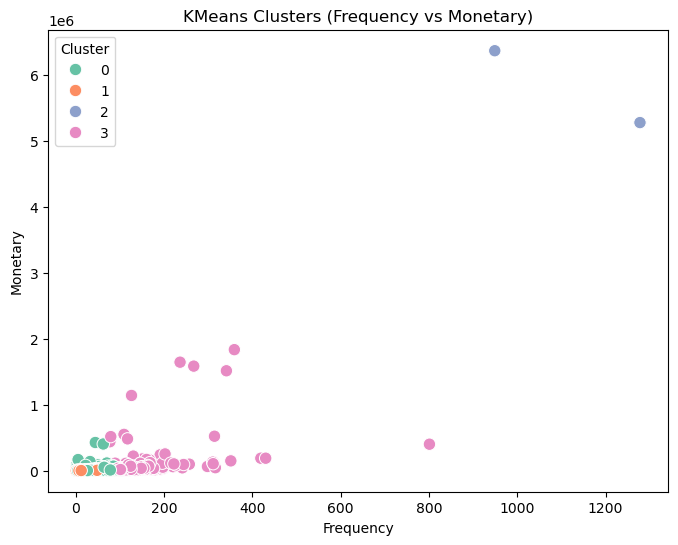

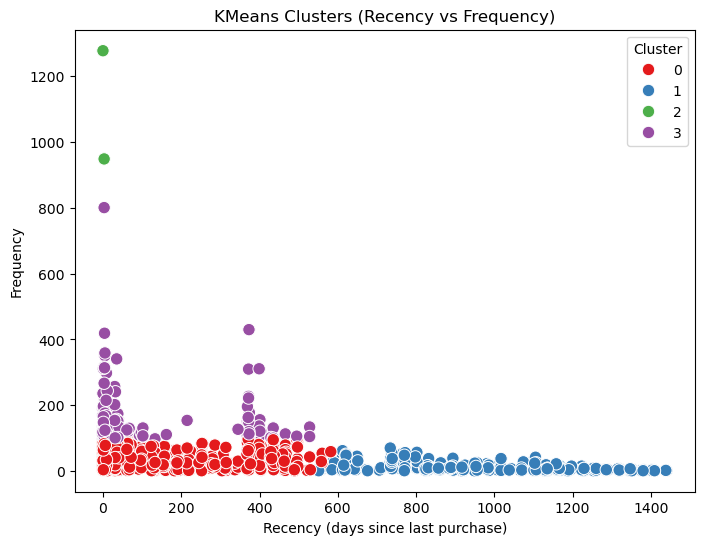

In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Select RFM features ---
rfm_features = rfm[['recency_days','frequency','monetary']]

# --- 2. Scale features ---
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# --- 3. Run KMeans ---
KMEANS_K = 4          # you can tune this (use elbow or silhouette method)
RANDOM_STATE = 42

kmeans = KMeans(n_clusters=KMEANS_K, n_init=10, random_state=RANDOM_STATE)
rfm['cluster_id'] = kmeans.fit_predict(rfm_scaled)

# --- 4. Cluster centroids (inverse-transform back to business scale) ---
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids, columns=['recency_days','frequency','monetary'])
centroids_df['cluster_id'] = range(KMEANS_K)

print("Cluster Profiles (Business Scale):")
print(centroids_df)

# --- 5. Visualize clusters ---
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm, x='frequency', y='monetary',
    hue='cluster_id', palette='Set2', s=80
)
plt.title("KMeans Clusters (Frequency vs Monetary)")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.legend(title="Cluster")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm, x='recency_days', y='frequency',
    hue='cluster_id', palette='Set1', s=80
)
plt.title("KMeans Clusters (Recency vs Frequency)")
plt.xlabel("Recency (days since last purchase)")
plt.ylabel("Frequency")
plt.legend(title="Cluster")
plt.show()


----
----

## <mark>need to optimise this below</mark>

## Soft Churn Windows & Features

In [35]:
# Define the windows
obs_end = cutoff_date - pd.Timedelta(days=CHURN_DAYS)
obs_start = obs_end - pd.Timedelta(days=OBSERVATION_DAYS)
churn_start = obs_end
churn_end = cutoff_date

**Observation window** = `obs_start, obs_end` → the “past” you use to compute features. <br>
In the observation window, we will collect customer behavior:
* How often they bought (frequency)
* How much they spent (monetary)
* Last purchase date (recency)
* Product mix, categories, etc.
<br>

**Churn window** = `churn_start, churn_end` → the “future” to check if retailer churn or not.

In [38]:
# Slice the transactions into windows
df_obs = df_sales[(df_sales['date'] >= obs_start) & (df_sales['date'] <= obs_end)].copy()
df_churn = df_sales[(df_sales['date'] > churn_start) & (df_sales['date'] <= churn_end)].copy()



# Group by the churn unit (retailer) and build features
grp_obs = df_obs.groupby('retailer_code', dropna=False)
def safe_div(a,b): 
    try:
        return a / b if b else 0.0
    except Exception:
        return 0.0



# Building the features
features = pd.DataFrame({
    'retailer_name': grp_obs['retailer_name'].agg(lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan),
    'retailer_type': grp_obs['retailer_type'].agg(lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan),
    'freq_txn': grp_obs['invoice_no'].nunique(),
    'monetary_total': grp_obs['invoice_value'].sum(),
    'qty_total': grp_obs['quantity_sold'].sum(),
    'unique_categories': grp_obs['product_category'].nunique(),
    'unique_brands': grp_obs['brand_name'].nunique(),
    'last_purchase_date_obs': grp_obs['date'].max(),
    'avg_discount': grp_obs.apply(lambda g: (g['list_price'] - g['price_sold']).mean() if len(g)>0 else 0.0),
    'avg_unit_price': grp_obs['price_sold'].mean(),
    'unit_price_std': grp_obs['price_sold'].std(),
}).reset_index()

features['recency_obs_days'] = (obs_end - features['last_purchase_date_obs']).dt.days
features['avg_basket_value'] = features.apply(lambda r: safe_div(r['monetary_total'], r['freq_txn']), axis=1)



# Merge in RFM scores
features = features.merge(rfm[['retailer_code','R_score','F_score','M_score']], on='retailer_code', how='left')



# Label churn: 1 if no txn in churn window
had_txn = df_churn.groupby('retailer_code')['invoice_no'].nunique().reset_index(name='churn_txn_count')
features = features.merge(had_txn, on='retailer_code', how='left')
features['churn_txn_count'] = features['churn_txn_count'].fillna(0).astype(int)
features['churn_label'] = (features['churn_txn_count'] == 0).astype(int)

features.sample(5)

C:\Users\seahx\AppData\Local\Temp\ipykernel_808\603010951.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  'avg_discount': grp_obs.apply(lambda g: (g['list_price'] - g['price_sold']).mean() if len(g)>0 else 0.0),


,retailer_code,retailer_name,retailer_type,freq_txn,monetary_total,qty_total,unique_categories,unique_brands,last_purchase_date_obs,avg_discount,avg_unit_price,unit_price_std,recency_obs_days,avg_basket_value,R_score,F_score,M_score,churn_txn_count,churn_label
124,352003b54f3fb8d26b3c35cac9ce4306f45f87a5,Retailer 269,CHAIN,2,881.00,306,2,2,2024-08-03,1.412500,3.987500,1.692789,41,440.500000,3,4,4,0,1
430,b93e572ebbe11d4279a74c1460e74d9a333d8cdb,Retailer 921,INDEPENDENT,8,2988.95,668,5,8,2024-09-12,3.036022,5.096237,1.673762,1,373.618750,4,4,4,6,0
447,c13ede40f11b22e69c3cbc5c124d0029d7e979a9,Retailer 956,INDEPENDENT,6,1331.30,438,5,7,2024-09-12,1.944898,3.910204,2.063396,1,221.883333,4,4,4,8,0
154,41bfc121e0adbfec5ca12c08763ba4f3cc34141e,Retailer 331,WHOLESALER,2,321.00,60,2,2,2024-08-11,2.375000,5.425000,0.410792,33,160.500000,4,2,3,2,0
150,3f431dac5540c66bbdd8664f90fd2b1640cff871,Retailer 322,INDEPENDENT,13,1470.65,311,5,7,2024-08-03,2.951190,5.277381,2.462356,41,113.126923,5,4,4,11,0


----
----

## Decision Tree Model

In [55]:

ml_df = features.copy()
if 'retailer_type' in ml_df.columns:
    ml_df = pd.get_dummies(ml_df, columns=['retailer_type'], drop_first=True)

X = ml_df.drop(columns=['retailer_name','last_purchase_date_obs','churn_txn_count','retailer_code','churn_label'], errors='ignore')
y = features['churn_label']
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)


# Splitting the training vs testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)


# Train the decision tree
clf = DecisionTreeClassifier(max_depth=MAX_DEPTH, min_samples_split=20, min_samples_leaf=10,
                             class_weight='balanced', random_state=RANDOM_STATE)
clf.fit(X_train, y_train)


# Make the predictions
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1]


# Evaluating performance
print(classification_report(y_test, y_pred, digits=3))
try:
    auc = roc_auc_score(y_test, y_proba)
    print('ROC AUC:', auc)
except ValueError:
    auc = float('nan')
    print('ROC AUC: nan')

cm = confusion_matrix(y_test, y_pred)
cm

              precision    recall  f1-score   support

           0      1.000     0.908     0.952        87
           1      0.805     1.000     0.892        33

    accuracy                          0.933       120
   macro avg      0.902     0.954     0.922       120
weighted avg      0.946     0.933     0.935       120

ROC AUC: 0.9710902124695229


array([[79,  8],
       [ 0, 33]], dtype=int64)

## Merging RFM and Churn prediction

In [59]:
# Add churn predictions to the original features DataFrame
features['churn_pred'] = clf.predict(X)
features['churn_proba'] = clf.predict_proba(X)[:,1]

# Merge features (with churn predictions) back to RFM DataFrame
rfm = rfm.merge(
    features[['retailer_code','churn_pred','churn_proba']], 
    on='retailer_code', 
    how='left'
)

In [61]:
rfm

,retailer_code,retailer_name,retailer_type,last_purchase_date,frequency,monetary,recency_days,R_score,F_score,M_score,RFM_Score,cluster_id,churn_pred_x,churn_proba_x,churn_pred_y,churn_proba_y
0,00008a663be95d5b9efc7b1b545c84fcccf5038f,Retailer 1,CHAIN,2023-03-04,45,15670.00,649,2,3,4,234,1,NaN,NaN,NaN,NaN
1,0015ceaefd4a6ce218f8567406ee8f2a6c057aa1,Retailer 2,CHAIN,2024-06-03,36,4325.85,192,3,3,3,333,0,1.0,1.0,1.0,1.0
2,002a005d0aca1e0a05853502c9a057b556126223,Retailer 3,OTHERS,2021-07-01,6,1358.25,1260,1,1,2,112,1,NaN,NaN,NaN,NaN
3,004c8a67e59c832776f3fb2f6e01dd503fd67553,Retailer 4,CHAIN,2023-12-05,107,30620.00,373,2,5,5,255,3,NaN,NaN,NaN,NaN
4,0093c186211ff95d706b1c44ca037dbd95869151,Retailer 5,INDEPENDENT,2024-11-11,2,741.00,31,4,1,1,411,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1167,ff48e49fb0ce7d3f8c50c4e5bf06e0bc3913c20d,Retailer 1272,MINIMART,2021-11-03,7,457.30,1135,1,1,1,111,1,NaN,NaN,NaN,NaN
1168,ff96de068bdadaaf69a818cf3e74583da0c993b3,Retailer 1273,CHAIN,2024-12-11,64,52433.70,1,5,4,5,545,0,0.0,0.0,0.0,0.0
1169,ffb13345310829eea23867a3ee6af3364d59ee45,Retailer 1274,INDEPENDENT,2024-12-06,78,11009.30,6,5,4,4,544,0,0.0,0.0,0.0,0.0
1170,ffba764f51c909da97092c220dba32c009d3a04b,Retailer 1275,INDEPENDENT,2024-02-01,26,1910.80,315,3,3,2,332,0,NaN,NaN,NaN,NaN


In [66]:
rfm_out_path2 = r"C:\Users\seahx\OneDrive\Documents\GitHub\bcg-rise-wave-11-group-2\Code\rfm_segments.csv"
rfm.to_csv(rfm_out_path, index=False)
rfm_out_path2

'C:\\Users\\seahx\\OneDrive\\Documents\\GitHub\\bcg-rise-wave-11-group-2\\Code\\rfm_segments.csv'